# Report 1 — Industry Tariff Impact (FF30 + ETF Event Study)

**Question:** did the 2025 US tariff announcements produce a measurable, statistically
distinguishable effect on returns for tariff-exposed industries (Autos, Steel, Semiconductors,
Health, Finance, Utilities)?

**Event window:** 2025-04-01 to 2025-09-30 (six months around the "Liberation Day" tariff
announcement and subsequent policy actions).
**Baseline window:** 2023-01-01 to 2025-03-31.

**Method:** market-model / Fama-French abnormal returns (AR), summed into a cumulative
abnormal return (CAR) per industry, tested for significance with both a parametric t-test and a
bootstrap. All CAR and significance logic lives in `src/regression.py`; this notebook drives it.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model

from data_fetch import (
    load_ff30_monthly, load_ff_factors_monthly, fetch_prices, daily_returns,
    FF3_MONTHLY_URL, FF5_MONTHLY_URL,
)
from regression import ff30_car_event, test_car_significance
from plotting import plot_car_curve, plot_industry_heatmap

plt.rcParams["figure.figsize"] = (9, 5)

START_DATE = "2023-01-01"
BASE_START, BASE_END = pd.Timestamp(START_DATE), pd.Timestamp("2025-03-31")
RECENT_START, RECENT_END = pd.Timestamp("2025-04-01"), pd.Timestamp("2025-09-30")
BENCH = "SPY"

ETF_MAP = {
    "Autos": "CARZ", "Steel": "XME", "TechSemis": "SOXX",
    "Health": "XLV", "Finance": "XLF", "Utilities": "XLU",
}
FF30_TO_ETF = {
    "Autos": ETF_MAP["Autos"], "Steel": ETF_MAP["Steel"], "BusEq": ETF_MAP["TechSemis"],
    "Hlth": ETF_MAP["Health"], "Fin": ETF_MAP["Finance"], "Util": ETF_MAP["Utilities"],
}
INDUSTRY_LABELS = {"Autos": "Autos", "Steel": "Steel", "BusEq": "Semis",
                    "Hlth": "Health", "Fin": "Finance", "Util": "Utilities"}

## Data

Daily ETF prices come from Yahoo Finance (`yfinance`); FF30 industry portfolios and Fama-French
3/5-factor data come from Ken French's data library. `load_ff30_monthly` (see `src/data_fetch.py`)
reads only the "Average Value Weighted Returns -- Monthly" table's own line range from the source
CSV — the original notebook's loader read to end-of-file and silently absorbed three other stacked
tables (equal-weighted returns, firm counts, firm size) under the same `YYYYMM` date format, which
was the root cause of Bug B (see `../CORRECTIONS.md`).

In [2]:
FF30 = load_ff30_monthly()
FF3M = load_ff_factors_monthly(FF3_MONTHLY_URL)
FF5M = load_ff_factors_monthly(FF5_MONTHLY_URL)

print("FF30 shape:", FF30.shape, "| columns:", len(FF30.columns))
print("FF3M shape:", FF3M.shape, "| FF5M shape:", FF5M.shape)

event_window_check = FF30.loc[(FF30.index >= RECENT_START) & (FF30.index <= RECENT_END)]
print("Rows in the Apr-Sep 2025 event window (should be 6):", len(event_window_check))
assert len(event_window_check) == 6, "FF30 event window is not 6 monthly rows -- loader regressed"

FF30 shape: (1200, 30) | columns: 30
FF3M shape: (1200, 4) | FF5M shape: (756, 6)
Rows in the Apr-Sep 2025 event window (should be 6): 6


In [3]:
etf_tickers = list(ETF_MAP.values())
px = fetch_prices(etf_tickers + [BENCH], START_DATE, "2025-09-30")
ret = daily_returns(px)
vol = px.copy()  # placeholder overwritten below with actual volume
logret = np.log(px / px.shift(1)).dropna()

# Volume needs a separate yfinance pull (Close-only download above doesn't include Volume)
import yfinance as yf
vol_raw = yf.download(etf_tickers + [BENCH], start=START_DATE, end="2025-09-30",
                       auto_adjust=True, progress=False)["Volume"]
vol = vol_raw

print(ret.shape, vol.shape, logret.shape)
ret.tail()

(686, 7) (687, 7) (686, 7)


Ticker,CARZ,SOXX,SPY,XLF,XLU,XLV,XME
Date,,,,,,,
2025-09-23,-0.002738,-0.001186,-0.005444,-0.004444,0.005164,0.002269,0.006158
2025-09-24,-0.002197,-0.001521,-0.003182,-0.002790,0.007123,-0.004016,-0.011147
2025-09-25,-0.002362,-0.003196,-0.004613,-0.002611,-0.009623,-0.016570,0.013484
2025-09-26,0.000000,0.002200,0.005729,0.007294,0.016273,0.010214,0.005453
2025-09-29,0.002770,0.000372,0.002810,0.005013,0.002880,0.002952,0.013883


## Daily ETF market-model abnormal returns

Demo on Autos (CARZ), then all six ETFs.

In [4]:
def expected_market_model(y, mkt):
    X = sm.add_constant(mkt.reindex(y.index))
    model = sm.OLS(y, X, missing="drop").fit()
    return model, model.predict(X)

def realized_volatility(lr, window=30):
    return (lr - lr.rolling(window).mean()).pow(2).rolling(window).sum().pow(0.5)

def volume_shock(v, window=60):
    return (v - v.rolling(window).median()) / v.rolling(window).median()

etf = "CARZ"
mod, exp = expected_market_model(ret[etf], ret[BENCH])
ar = (ret[etf] - exp).dropna()
print(f"{etf}: R2={mod.rsquared:.3f}  mean AR={ar.mean():.5f}  std AR={ar.std():.5f}")

CARZ: R2=0.663  mean AR=0.00000  std AR=0.00939


In [5]:
def _slice(df, start, end):
    return df.loc[(df.index >= start) & (df.index <= end)]

def etf_metrics_window(etf, start, end):
    y = _slice(ret[[etf]], start, end)[etf]
    m = _slice(ret[[BENCH]], start, end)[BENCH]
    v = _slice(vol[[etf]], start, end)[etf]
    lr = _slice(logret[[etf]], start, end)[etf]

    if len(y) < 60:
        return {k: np.nan for k in [
            "ETF_R2", "ETF_Mean_AR", "ETF_Std_AR", "ETF_RealVol_30d_avg",
            "ETF_VolShock_avg", "GARCH_AIC", "GARCH_BIC", "GARCH_LB_p",
        ]}

    X = sm.add_constant(m.reindex(y.index))
    model = sm.OLS(y, X, missing="drop").fit()
    ar = (y - model.predict(X)).dropna()
    rv = realized_volatility(lr, 30)
    vs = volume_shock(v, 60)

    g_stats = {"GARCH_AIC": np.nan, "GARCH_BIC": np.nan, "GARCH_LB_p": np.nan}
    try:
        series = (y.dropna() * 100)
        if len(series) >= 100:
            am = arch_model(series, vol="GARCH", p=1, q=1, dist="normal")
            res = am.fit(disp="off")
            lb = acorr_ljungbox(res.std_resid.dropna(), lags=[10], return_df=True)
            g_stats = {"GARCH_AIC": res.aic, "GARCH_BIC": res.bic,
                       "GARCH_LB_p": float(lb["lb_pvalue"].iloc[0])}
    except Exception:
        pass

    return {
        "ETF_R2": model.rsquared, "ETF_Mean_AR": float(ar.mean()), "ETF_Std_AR": float(ar.std()),
        "ETF_RealVol_30d_avg": float(rv.mean()), "ETF_VolShock_avg": float(vs.mean()), **g_stats,
    }

daily_metrics_rows = []
for ff_ind, etf in FF30_TO_ETF.items():
    m_recent = etf_metrics_window(etf, RECENT_START, RECENT_END)
    m_base = etf_metrics_window(etf, BASE_START, BASE_END)
    daily_metrics_rows.append({"Industry": INDUSTRY_LABELS[ff_ind], "ETF": etf,
                                **{f"BASE_{k}": v for k, v in m_base.items()},
                                **{f"RECENT_{k}": v for k, v in m_recent.items()}})

daily_metrics_df = pd.DataFrame(daily_metrics_rows).set_index(["Industry", "ETF"])
daily_metrics_df.round(4)

,,BASE_ETF_R2,BASE_ETF_Mean_AR,BASE_ETF_Std_AR,BASE_ETF_RealVol_30d_avg,BASE_ETF_VolShock_avg,BASE_GARCH_AIC,BASE_GARCH_BIC,BASE_GARCH_LB_p,RECENT_ETF_R2,RECENT_ETF_Mean_AR,RECENT_ETF_Std_AR,RECENT_ETF_RealVol_30d_avg,RECENT_ETF_VolShock_avg,RECENT_GARCH_AIC,RECENT_GARCH_BIC,RECENT_GARCH_LB_p
Industry,ETF,,,,,,,,,,,,,,,,
Autos,CARZ,0.6235,-0.0,0.0091,0.0763,0.7618,2032.5470,2049.8659,0.3807,0.7601,0.0,0.0103,0.0644,1.8490,462.6708,473.9841,0.4340
Steel,XME,0.3924,-0.0,0.0125,0.0844,0.0370,2126.1103,2143.4292,0.3587,0.5122,-0.0,0.0140,0.0852,0.1653,497.4729,508.7862,0.2120
Semis,SOXX,0.5991,-0.0,0.0128,0.1047,0.1301,2373.1000,2390.4189,0.8432,0.8212,-0.0,0.0115,0.0738,0.1508,512.6033,523.9166,0.1969
Health,XLV,0.2997,-0.0,0.0060,0.0377,0.0347,1224.7517,1242.0706,0.9540,0.4142,-0.0,0.0097,0.0508,0.0416,394.0245,405.3377,0.5938
Finance,XLF,0.5217,0.0,0.0067,0.0491,0.0690,1520.2018,1537.5207,0.6509,0.8449,-0.0,0.0055,0.0445,0.0156,361.3892,372.7024,0.0928
Utilities,XLU,0.1154,0.0,0.0099,0.0556,0.0620,1655.8872,1673.2060,0.2861,0.3516,-0.0,0.0086,0.0423,0.0349,347.6883,359.0016,0.3254


## Event-study CARs (baseline-fit, applied to the Apr-Sep 2025 event window)

Both the ETF (daily) and FF30 (monthly) CARs use `ff30_car_event` / an equivalent market-model
fit-then-apply approach: the factor model is estimated on the 2023-01-01 to 2025-03-31 baseline,
then applied out-of-sample to the event window to get abnormal returns. This is the corrected,
single implementation — the original notebook had three near-duplicate versions of this logic
(cells 18, 23, 44) that inherited the corrupted FF30 frame and diverged in their minimum-N guards.

In [6]:
def etf_car_event(etf, base_start, base_end, event_start, event_end):
    y_base = _slice(ret[[etf]], base_start, base_end)[etf]
    m_base = _slice(ret[[BENCH]], base_start, base_end)[BENCH]
    if len(y_base) < 60:
        return np.nan, pd.Series(dtype=float)
    Xb = sm.add_constant(m_base)
    mod = sm.OLS(y_base, Xb, missing="drop").fit()

    y_event = _slice(ret[[etf]], event_start, event_end)[etf]
    m_event = _slice(ret[[BENCH]], event_start, event_end)[BENCH]
    Xe = sm.add_constant(m_event.reindex(y_event.index))
    ar = (y_event - mod.predict(Xe)).dropna()
    return float(ar.sum()), ar

results = []
for ff_ind, etf in FF30_TO_ETF.items():
    etf_car, etf_ar = etf_car_event(etf, BASE_START, BASE_END, RECENT_START, RECENT_END)
    t_etf, p_etf, pb_etf = test_car_significance(etf_ar)

    ff3_car, ff3_ar = ff30_car_event(FF30, FF3M, FF5M, ff_ind, BASE_START, BASE_END,
                                      RECENT_START, RECENT_END, "FF3")
    t_ff3, p_ff3, pb_ff3 = test_car_significance(ff3_ar)

    ff5_car, ff5_ar = ff30_car_event(FF30, FF3M, FF5M, ff_ind, BASE_START, BASE_END,
                                      RECENT_START, RECENT_END, "FF5")
    t_ff5, p_ff5, pb_ff5 = test_car_significance(ff5_ar)

    results.append({
        "Industry": INDUSTRY_LABELS[ff_ind], "ETF": etf,
        "ETF_CAR": etf_car, "ETF_N": len(etf_ar), "ETF_t": t_etf, "ETF_p_boot": pb_etf,
        "FF3_CAR": ff3_car, "FF3_N": len(ff3_ar), "FF3_t": t_ff3, "FF3_p_boot": pb_ff3,
        "FF5_CAR": ff5_car, "FF5_N": len(ff5_ar), "FF5_t": t_ff5, "FF5_p_boot": pb_ff5,
    })

car_summary = pd.DataFrame(results).set_index(["Industry", "ETF"])
car_summary.round(4)

,,ETF_CAR,ETF_N,ETF_t,ETF_p_boot,FF3_CAR,FF3_N,FF3_t,FF3_p_boot,FF5_CAR,FF5_N,FF5_t,FF5_p_boot
Industry,ETF,,,,,,,,,,,,
Autos,CARZ,0.1270,125,1.0709,0.513,0.0012,6,0.0035,0.992,0.0681,6,0.1996,0.827
Steel,XME,0.3794,125,2.3602,0.497,0.0061,6,0.0684,0.945,0.1324,6,1.2056,0.501
Semis,SOXX,0.0914,125,0.6856,0.576,0.0733,6,1.1364,0.529,0.0886,6,1.3073,0.510
Health,XLV,-0.1242,125,-1.1304,0.486,-0.0482,6,-0.4849,0.597,-0.0584,6,-0.5497,0.585
Finance,XLF,-0.0741,125,-1.2117,0.496,-0.0669,6,-1.9824,0.504,-0.0645,6,-1.2757,0.535
Utilities,XLU,0.0322,125,0.3335,0.751,-0.0052,6,-0.0835,0.936,-0.0137,6,-0.1552,0.899


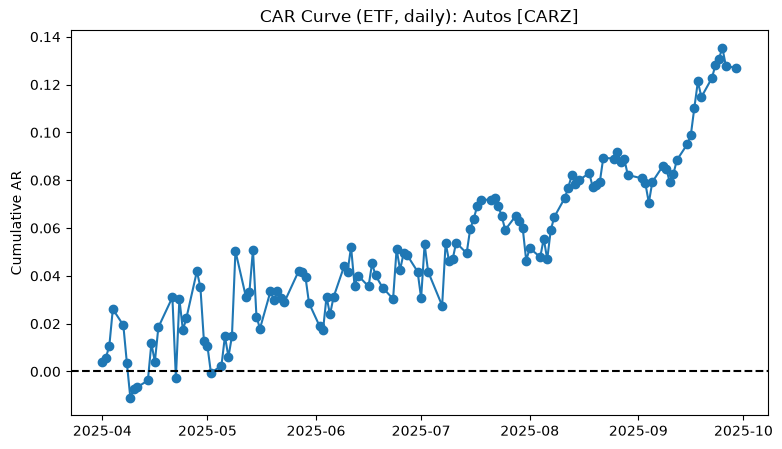

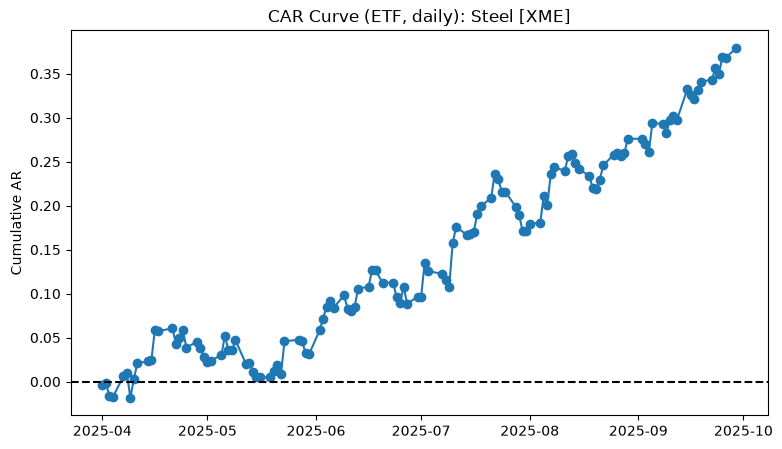

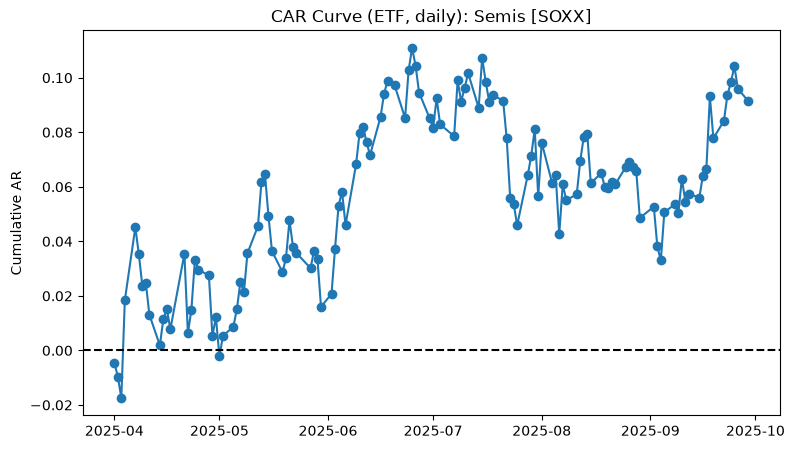

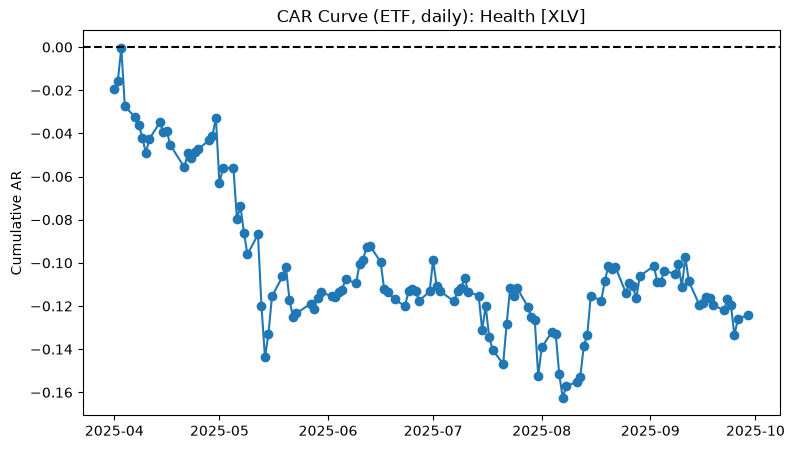

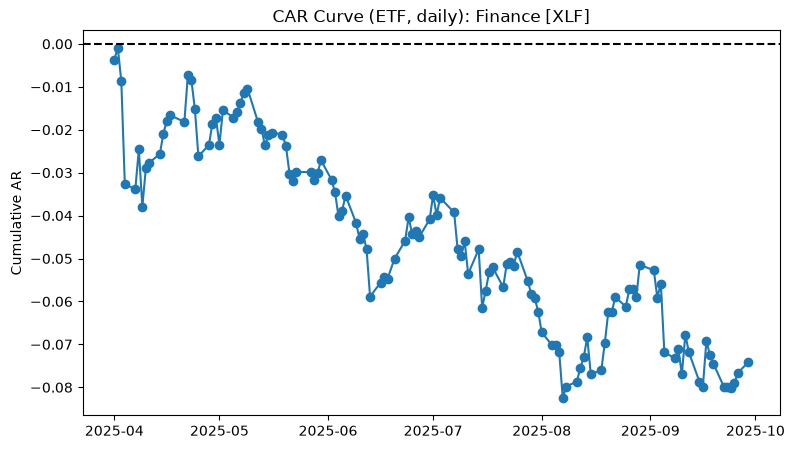

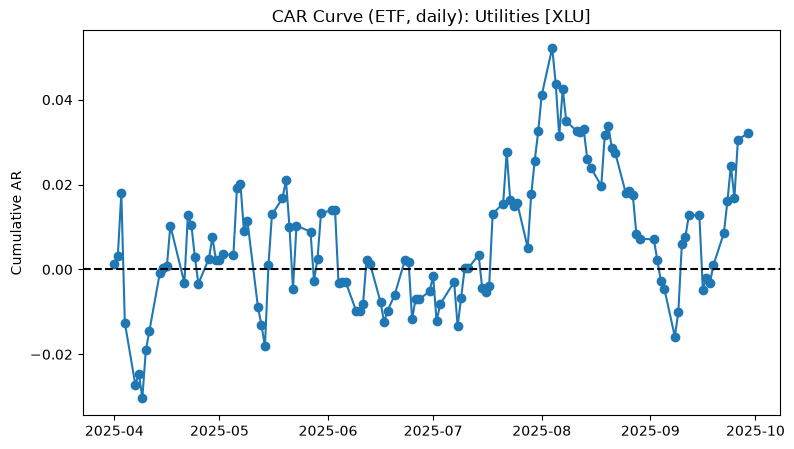

In [7]:
for (industry, etf), row in car_summary.iterrows():
    _, ar = etf_car_event(etf, BASE_START, BASE_END, RECENT_START, RECENT_END)
    plot_car_curve(ar, f"CAR Curve (ETF, daily): {industry} [{etf}]")
    plt.savefig(f"../figures/car_etf_{industry.lower()}.png", dpi=110, bbox_inches="tight")
    plt.show()

## Corrected industry ranking — the blocking check

The original notebook ranked Autos, Semis, and Steel as the most tariff-affected industries by
FF30 CAR magnitude, and Report 2's 15-stock portfolio was built on that ranking. Re-running the
ranking after fixing Bugs A and B does **not** reproduce that result cleanly: it depends on which
model you use, and none of the industry CARs are statistically distinguishable from noise in any
specification (bootstrap p-values all sit around 0.5-0.9). See `../CORRECTIONS.md` for the full
comparison across FF3, FF5, and the ETF market-model. Report 2 is published as analysis of a
**pre-selected** tariff-exposed basket, not as analysis of a validated "most-affected" ranking.

In [8]:
ranking = car_summary.reset_index()[["Industry", "ETF", "FF3_CAR", "FF5_CAR", "ETF_CAR"]].copy()
ranking["abs_FF3_CAR"] = ranking["FF3_CAR"].abs()
ranking = ranking.sort_values("abs_FF3_CAR", ascending=False).drop(columns="abs_FF3_CAR")
print("Corrected ranking by |FF3 CAR| (most- to least-affected):")
ranking

Corrected ranking by |FF3 CAR| (most- to least-affected):


,Industry,ETF,FF3_CAR,FF5_CAR,ETF_CAR
2,Semis,SOXX,0.073307,0.088612,0.091373
4,Finance,XLF,-0.066869,-0.064498,-0.074107
3,Health,XLV,-0.048184,-0.058376,-0.124165
1,Steel,XME,0.006149,0.132401,0.379390
5,Utilities,XLU,-0.005227,-0.013650,0.032182
0,Autos,CARZ,0.001239,0.068098,0.126972


## Statistical power: could this design have detected a plausible industry effect?

A null result ("no industry CAR is significant") is a different claim from "this design could
have detected an effect if one existed." Below: the minimum detectable effect (MDE) at 80% power
for each industry/model, derived algebraically from the CAR and t-stat already computed above
(`sigma = CAR / (t*sqrt(N))`, so `MDE = z_combined * CAR / t` — see `src/regression.py::car_mde`).
No new fetch, no new specification — this describes the power of the test already run.

In [9]:
Z_COMBINED = 2.801585  # z(0.975) + z(0.80), two-sided alpha=0.05, 80% power

power_rows = []
for (industry, etf), row in car_summary.iterrows():
    row_data = {"Industry": industry, "ETF": etf}
    for spec, car_col, t_col, n_col in [("ETF", "ETF_CAR", "ETF_t", "ETF_N"),
                                          ("FF3", "FF3_CAR", "FF3_t", "FF3_N"),
                                          ("FF5", "FF5_CAR", "FF5_t", "FF5_N")]:
        car, t, n = row[car_col], row[t_col], row[n_col]
        mde = Z_COMBINED * abs(car / t) if t != 0 else np.nan
        row_data[f"{spec}_N"] = n
        row_data[f"{spec}_CAR"] = car
        row_data[f"{spec}_MDE"] = mde
    power_rows.append(row_data)

industry_power_table = pd.DataFrame(power_rows).set_index(["Industry", "ETF"])
industry_power_table.round(4)

,,ETF_N,ETF_CAR,ETF_MDE,FF3_N,FF3_CAR,FF3_MDE,FF5_N,FF5_CAR,FF5_MDE
Industry,ETF,,,,,,,,,
Autos,CARZ,125.0,0.1270,0.3322,6.0,0.0012,0.9988,6.0,0.0681,0.9560
Steel,XME,125.0,0.3794,0.4503,6.0,0.0061,0.2517,6.0,0.1324,0.3077
Semis,SOXX,125.0,0.0914,0.3734,6.0,0.0733,0.1807,6.0,0.0886,0.1899
Health,XLV,125.0,-0.1242,0.3077,6.0,-0.0482,0.2784,6.0,-0.0584,0.2975
Finance,XLF,125.0,-0.0741,0.1713,6.0,-0.0669,0.0945,6.0,-0.0645,0.1416
Utilities,XLU,125.0,0.0322,0.2703,6.0,-0.0052,0.1753,6.0,-0.0137,0.2464


**Was this design capable of detecting a plausible tariff effect? No — substantially
underpowered, at both the daily-ETF and monthly-FF30 layers.** ETF-based MDEs run roughly
17-45% over six months; FF30-based MDEs run roughly 9-31% for five of the six industries. (Autos
is a degenerate case here — its FF3 and FF5 t-stats are both close to zero, which makes the
algebraic `sigma = CAR/(t*sqrt(N))` recovery numerically unstable and produces an MDE near 100%.
That is an artifact of dividing by a near-zero t-stat, not a real detection threshold — read
Autos'''s FF3/FF5 MDE as "not meaningfully estimable from this table," not as "100% required.")
Compare the stable estimates to what a real tariff effect might plausibly look like: single-digit
to low-double-digit percentage moves over six months, not the 20%+ swings this design would need
to reliably detect. Only Steel'''s ETF-based CAR (37.9% observed vs. ~45% MDE) comes close to the
detection threshold; every other industry/model combination sits well below it. **The honest
conclusion is "this design could not have detected an industry effect of plausible size," not
"there is no industry effect."** That is a materially different — and more defensible — claim
than the null on its own, and it is the correct way to read every CAR result in this notebook.

## Comparative view: CAR + volatility + volume shock, by industry

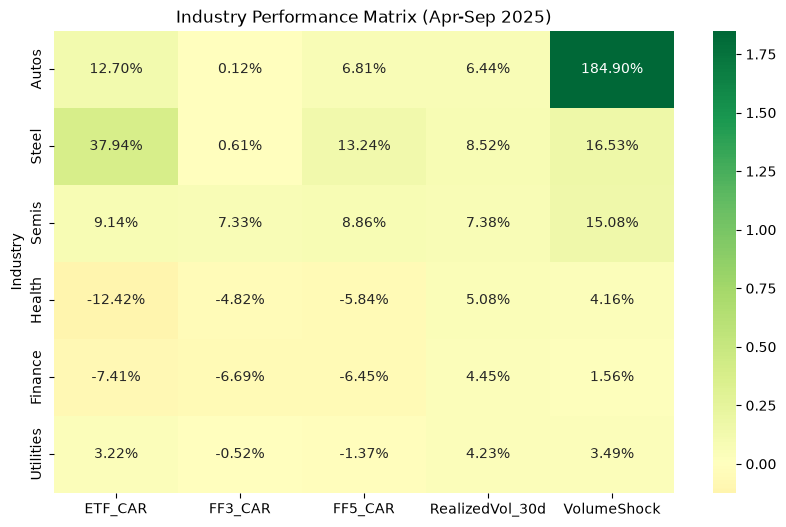

,ETF_CAR,FF3_CAR,FF5_CAR,RealizedVol_30d,VolumeShock
Industry,,,,,
Autos,0.1270,0.0012,0.0681,0.0644,1.8490
Steel,0.3794,0.0061,0.1324,0.0852,0.1653
Semis,0.0914,0.0733,0.0886,0.0738,0.1508
Health,-0.1242,-0.0482,-0.0584,0.0508,0.0416
Finance,-0.0741,-0.0669,-0.0645,0.0445,0.0156
Utilities,0.0322,-0.0052,-0.0137,0.0423,0.0349


In [10]:
matrix_rows = []
for (industry, etf), row in car_summary.iterrows():
    ff_ind = [k for k, v in INDUSTRY_LABELS.items() if v == industry][0]
    dm = daily_metrics_df.loc[(industry, etf)]
    matrix_rows.append({
        "Industry": industry, "ETF_CAR": row["ETF_CAR"], "FF3_CAR": row["FF3_CAR"],
        "FF5_CAR": row["FF5_CAR"], "RealizedVol_30d": dm["RECENT_ETF_RealVol_30d_avg"],
        "VolumeShock": dm["RECENT_ETF_VolShock_avg"],
    })
industry_matrix = pd.DataFrame(matrix_rows).set_index("Industry")
plot_industry_heatmap(industry_matrix, "Industry Performance Matrix (Apr-Sep 2025)")
plt.savefig("../figures/industry_performance_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
industry_matrix.round(4)

## Industry CAR timeline with tariff events

Illustrative overlay of the ETF CAR curves against the major 2025 tariff policy dates. This is a
narrative visualization, not itself a significance test — see the CAR summary table above and
`../CORRECTIONS.md` for which of these moves are statistically distinguishable from noise (none,
at conventional thresholds).

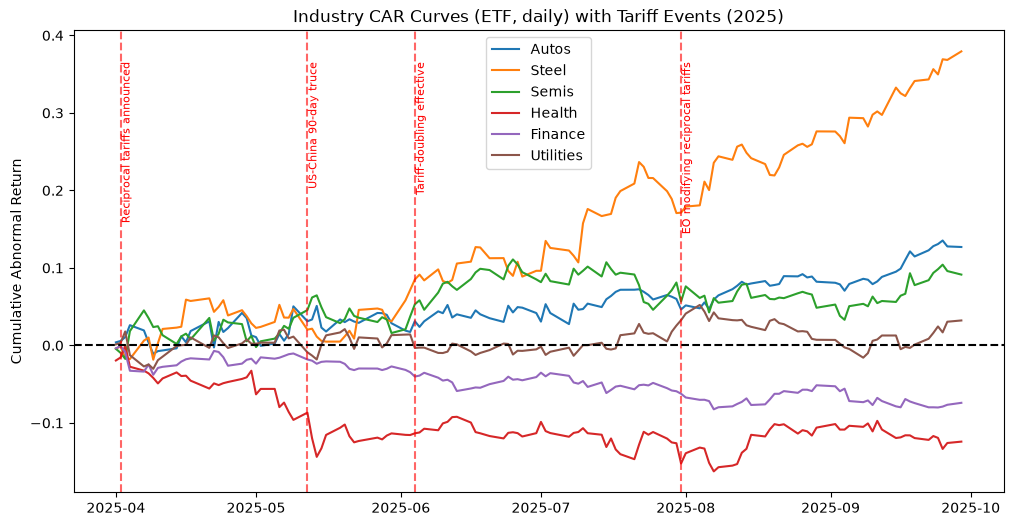

In [11]:
events = [
    {"date": "2025-04-02", "label": "Reciprocal tariffs announced"},
    {"date": "2025-05-12", "label": "US-China 90-day truce"},
    {"date": "2025-06-04", "label": "Tariff-doubling effective"},
    {"date": "2025-07-31", "label": "EO modifying reciprocal tariffs"},
]

fig, ax = plt.subplots(figsize=(12, 6))
for (industry, etf), row in car_summary.iterrows():
    _, ar = etf_car_event(etf, BASE_START, BASE_END, RECENT_START, RECENT_END)
    ax.plot(ar.cumsum().index, ar.cumsum().values, label=industry)

for ev in events:
    d = pd.to_datetime(ev["date"])
    ax.axvline(d, color="red", linestyle="--", alpha=0.6)
    ax.text(d, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] else 0.05, ev["label"],
            rotation=90, color="red", va="top", fontsize=8)

ax.axhline(0, color="black", linestyle="--")
ax.set_title("Industry CAR Curves (ETF, daily) with Tariff Events (2025)")
ax.set_ylabel("Cumulative Abnormal Return")
ax.legend()
plt.savefig("../figures/industry_car_timeline.png", dpi=110, bbox_inches="tight")
plt.show()

## Q4 2025 outlook (hybrid CAR + volatility + momentum)

Forward-looking, GARCH-volatility-based outlook built by the team from the corrected CAR and
volatility inputs above. This is a model-driven extrapolation, not a forecast guarantee — the
CAR inputs feeding it are not individually significant (see above), so read the ranking here as
indicative, not causal.

In [12]:
q4_rows = []
for (industry, etf), row in car_summary.iterrows():
    dm = daily_metrics_df.loc[(industry, etf)]
    y_recent = _slice(ret[[etf]], RECENT_START, RECENT_END)[etf]
    slope_60d = y_recent.tail(60).mean() * 60 if len(y_recent) >= 60 else np.nan
    q4_rows.append({
        "Industry": industry,
        "AnnVol_Q4_Forecast": dm["RECENT_ETF_RealVol_30d_avg"] * np.sqrt(252) if pd.notna(dm["RECENT_ETF_RealVol_30d_avg"]) else np.nan,
        "CAR_Slope_60d": slope_60d,
        "GARCH_LB_p": dm["RECENT_GARCH_LB_p"],
    })
q4_outlook = pd.DataFrame(q4_rows).set_index("Industry").sort_values("CAR_Slope_60d", ascending=False)
q4_outlook.round(4)

,AnnVol_Q4_Forecast,CAR_Slope_60d,GARCH_LB_p
Industry,,,
Steel,1.3532,0.2974,0.2120
Autos,1.0227,0.1480,0.4340
Semis,1.1723,0.1069,0.1969
Utilities,0.6710,0.0704,0.3254
Finance,0.7063,0.0226,0.0928
Health,0.8061,0.0102,0.5938


## Cross-sectional dispersion

Dispersion of FF30 monthly industry returns, baseline vs. event window — a measure of how much
industries diverged from each other (not from the market), regardless of direction.

In [13]:
csd_base = FF30.loc[(FF30.index >= BASE_START) & (FF30.index <= BASE_END)].std(axis=1)
csd_recent = FF30.loc[(FF30.index >= RECENT_START) & (FF30.index <= RECENT_END)].std(axis=1)
print(f"Cross-sectional dispersion (avg monthly std across industries):")
print(f"  Baseline (2023-01 to 2025-03): {csd_base.mean():.4f}")
print(f"  Event window (Apr-Sep 2025):   {csd_recent.mean():.4f}")

Cross-sectional dispersion (avg monthly std across industries):
  Baseline (2023-01 to 2025-03): 0.0486
  Event window (Apr-Sep 2025):   0.0509


## Risk-adjusted CAR efficiency

Sharpe-style AR efficiency and CAR-per-unit-of-volatility, using the same single consolidated
`ff30_car_event` / market-model functions as above — no separate re-implementation.

In [14]:
def sharpe_like(ar, freq):
    if ar is None or len(ar) < 3:
        return np.nan
    mu, sd = np.mean(ar), np.std(ar, ddof=1)
    return np.nan if (sd == 0 or np.isnan(sd)) else float(mu / sd * np.sqrt(freq))

def car_per_vol_t(ar, car):
    if ar is None or len(ar) < 3:
        return np.nan
    sd, n = np.std(ar, ddof=1), len(ar)
    return np.nan if (sd == 0 or np.isnan(sd)) else float(car / (sd * np.sqrt(n)))

efficiency_rows = []
for ff_ind, etf in FF30_TO_ETF.items():
    etf_car, etf_ar = etf_car_event(etf, BASE_START, BASE_END, RECENT_START, RECENT_END)
    ff3_car, ff3_ar = ff30_car_event(FF30, FF3M, FF5M, ff_ind, BASE_START, BASE_END,
                                      RECENT_START, RECENT_END, "FF3")
    ff5_car, ff5_ar = ff30_car_event(FF30, FF3M, FF5M, ff_ind, BASE_START, BASE_END,
                                      RECENT_START, RECENT_END, "FF5")
    efficiency_rows.append({
        "Industry": INDUSTRY_LABELS[ff_ind], "ETF": etf,
        "ETF_CAR": etf_car, "ETF_Sharpe_ann": sharpe_like(etf_ar, 252),
        "ETF_CAR_perVol_t": car_per_vol_t(etf_ar, etf_car), "ETF_N": len(etf_ar),
        "FF3_CAR": ff3_car, "FF3_Sharpe_ann": sharpe_like(ff3_ar, 12),
        "FF3_CAR_perVol_t": car_per_vol_t(ff3_ar, ff3_car), "FF3_N": len(ff3_ar),
        "FF5_CAR": ff5_car, "FF5_Sharpe_ann": sharpe_like(ff5_ar, 12),
        "FF5_CAR_perVol_t": car_per_vol_t(ff5_ar, ff5_car), "FF5_N": len(ff5_ar),
    })
efficiency_table = pd.DataFrame(efficiency_rows).set_index(["Industry", "ETF"]).round(4)
efficiency_table

,,ETF_CAR,ETF_Sharpe_ann,ETF_CAR_perVol_t,ETF_N,FF3_CAR,FF3_Sharpe_ann,FF3_CAR_perVol_t,FF3_N,FF5_CAR,FF5_Sharpe_ann,FF5_CAR_perVol_t,FF5_N
Industry,ETF,,,,,,,,,,,,
Autos,CARZ,0.1270,1.5205,1.0709,125,0.0012,0.0049,0.0035,6,0.0681,0.2822,0.1996,6
Steel,XME,0.3794,3.3511,2.3602,125,0.0061,0.0968,0.0684,6,0.1324,1.7049,1.2056,6
Semis,SOXX,0.0914,0.9735,0.6856,125,0.0733,1.6071,1.1364,6,0.0886,1.8488,1.3073,6
Health,XLV,-0.1242,-1.6051,-1.1304,125,-0.0482,-0.6858,-0.4849,6,-0.0584,-0.7774,-0.5497,6
Finance,XLF,-0.0741,-1.7204,-1.2117,125,-0.0669,-2.8036,-1.9824,6,-0.0645,-1.8041,-1.2757,6
Utilities,XLU,0.0322,0.4736,0.3335,125,-0.0052,-0.1181,-0.0835,6,-0.0137,-0.2195,-0.1552,6


## Final integrated view

In [15]:
final_dashboard = car_summary.reset_index()[["Industry", "ETF", "ETF_CAR", "FF3_CAR", "FF5_CAR"]].merge(
    q4_outlook.reset_index(), on="Industry"
).set_index("Industry")
final_dashboard.round(4)

,ETF,ETF_CAR,FF3_CAR,FF5_CAR,AnnVol_Q4_Forecast,CAR_Slope_60d,GARCH_LB_p
Industry,,,,,,,
Autos,CARZ,0.1270,0.0012,0.0681,1.0227,0.1480,0.4340
Steel,XME,0.3794,0.0061,0.1324,1.3532,0.2974,0.2120
Semis,SOXX,0.0914,0.0733,0.0886,1.1723,0.1069,0.1969
Health,XLV,-0.1242,-0.0482,-0.0584,0.8061,0.0102,0.5938
Finance,XLF,-0.0741,-0.0669,-0.0645,0.7063,0.0226,0.0928
Utilities,XLU,0.0322,-0.0052,-0.0137,0.6710,0.0704,0.3254


## Limitations of the analysis

1. **Industry classification mismatch.** FF30 portfolios are academic constructs (value-weighted,
   annually reformed) that report one observation per month; ETFs are market-tradable and update
   every trading day. Comparing a monthly series against a daily one introduces a measurement-
   granularity mismatch, reflected in the FF3/FF5 vs. ETF CAR disagreement above.
2. **No individual industry CAR is statistically significant** at conventional thresholds once the
   significance-test formula is corrected (Bug A) — bootstrap p-values sit around 0.5-0.9 across
   every industry and every model specification. The "most-affected industries" framing in the
   original write-up should be read as descriptive ranking of point estimates, not as a tested
   finding.
3. **This design is underpowered, not just null.** The FF30 monthly event window has only 6
   observations; the ETF daily window has ~125. The power analysis above quantifies exactly what
   that costs: MDEs of roughly 17-45% (ETF) and 9-31% (FF30, for five of six industries), against plausible tariff
   effects of single- to low-double-digit percent. This isn't a caveat on the null result — it's
   the reason the null result alone doesn't tell you whether a real (smaller) effect exists.
4. **Rerun caveat.** yfinance returns split/dividend-adjusted prices, so a rerun on a later date
   will not exactly reproduce these figures even with identical code — see the README for the
   pinned rerun date and what changed between runs.